## Comparing Dynamic Operability Mapping Methods for a Membrane Reactor

Author: Victor Alves - Carnegie Mellon University

opyrability can map the dynamic achievable output funnel three ways, each trading model fidelity against computational cost:

| Method | Model it needs | State dimension | Cost | Exact? | State funnel? |
|---|---|---|---|---|---|
| Linear state-space projection {cite}`dinh26` | LTI matrices $\{A, B, C\}$ | Low (matrices given) | Seconds | Exact for the LTI model | Yes |
| Nonlinear state-space projection | Step model $f(x,u)$ | Low ($\lesssim 8$ states) | Seconds | Convex-hull approximation | Yes |
| n-step simulation {cite}`dinh23` | Step model $f(x,u)$ | **Any** | Minutes | Boundary-tracking approximation | No |

A first-principles model like the DMA-MR carries 160 states, far too many for the projection methods, which propagate state-space polytopes. The practical route is to apply the projection methods to **reduced models derived from the rigorous one**, which is what this tutorial demonstrates on the co-current DMA-MR:

-  the **n-step method on the full 160-state model** gives the reference funnel;
-  a **linear model identified from step tests** feeds the fast linear projection, exactly as the HYPER model of {cite}`dinh26` was identified from its physical facility;
-  a **low-order nonlinear surrogate** (nonlinear steady-state gains with identified first-order dynamics) feeds the nonlinear projection.

The three funnels are overlaid in one interactive plot, and the dOI of each method is compared against the reference.

The process is the co-current DMA-MR from the [dynamic operability tutorial](dynamic_dma_mr.ipynb): manipulated inputs are the tube and shell flowrates ($\pm 200$ dm³/h around the nominal point), outputs are the benzene and hydrogen mole fractions, and the methane feed is held at its nominal value of $94.2\%$. The same AIS, DOS, initial steady state, and 8 minute horizon are used for all three methods, so any difference between the funnels comes from the method and its model, not from the problem setup.

Let's start by importing the packages and the DMA-MR dynamic model:

In [1]:
import sys, os, time
import numpy as np
import matplotlib.pyplot as plt

# Reuse the co-current DMA-MR dynamic model that ships with opyrability's
# test suite (the same model written out in full in the dynamic operability
# tutorial), instead of repeating its ~200 lines here.
_tests_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'tests'))
if _tests_dir not in sys.path:
    sys.path.insert(0, _tests_dir)

from dma_mr import (dma_mr_cocurrent_x0,
                    dma_mr_cocurrent_step,
                    dma_mr_cocurrent_outputs)

# Plotly renderer that stays interactive in the compiled
# documentation website (loads plotly.js via require.js).
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

plt.rcParams['figure.dpi'] = 150

Then, defining the operating point and the operability sets shared by all three methods:

In [2]:
Qt_nom, Qs_nom, d_nom = 800.0, 1200.0, 94.2
u_ref = np.array([Qt_nom, Qs_nom])

# Initial condition: the steady state at the nominal point (full model)
x0_full = dma_mr_cocurrent_x0([Qt_nom, Qs_nom], d=d_nom)
y_ref = dma_mr_cocurrent_outputs(x0_full)
print(f'Nominal steady state: benzene = {y_ref[0]:.2f} %, H2 = {y_ref[1]:.2f} %')

AIS_bounds = np.array([[Qt_nom - 200, Qt_nom + 200],
                       [Qs_nom - 200, Qs_nom + 200]])
DOS_bounds = np.array([[5.0,  9.0],
                       [19.0, 24.0]])
k_max = 8

output_labels = ['Benzene mole fraction [%]', 'H2 mole fraction [%]']

Nominal steady state: benzene = 6.61 %, H2 = 21.96 %


### Mapping the reference funnel with the n-step method (full model)

The n-step simulation method works directly on the rigorous 160-state model: it propagates exact state vectors through the transient simulator and takes convex hulls only in the output space. It is the most faithful of the three (its only approximation is the boundary tracking of the reachable set) and serves as the reference here. The initial output slice is omitted (``y0=None``) so that all three methods produce funnels indexed identically at $k = 1, \dots, 8$.

Importing opyrability's dynamic operability module:

In [3]:
from opyrability import dynamic_operability

In [4]:
def full_model_step(x, u):
    return dma_mr_cocurrent_step(x, u, d=d_nom)

start = time.time()
res_nstep = dynamic_operability(full_model_step,
                                x0_full,
                                AIS_bounds,
                                DOS=DOS_bounds,
                                k_max=k_max,
                                method='nstep',
                                plot=False)
t_nstep = time.time() - start
print(f'n-step (full model): {t_nstep:.1f} s')
print(f'dOI: {np.round(res_nstep["dOI"], 1)}')

n-step (full model): 40.7 s
dOI: [ 0.5  1.   2.2  4.3  7.7 11.4 14.2 17.7]


### Identifying a linear model from step tests

The linear projection method needs LTI matrices, which a 160-state nonlinear reactor does not directly provide. The standard route is system identification: step each input on the rigorous simulator, record the output responses, and fit a first-order transfer function per channel. Each fitted entry contributes one state, giving a 4-state model exactly like the identified HYPER model of {cite}`dinh26`:

In [5]:
# Step tests: +200 dm3/h on each input, 25 minutes
n_test = 25
responses = {}
start = time.time()
for j, du in enumerate([np.array([200.0, 0.0]), np.array([0.0, 200.0])]):
    M = x0_full.copy()
    ys = []
    for k in range(n_test):
        M, y = dma_mr_cocurrent_step(M, u_ref + du, d=d_nom)
        ys.append(y - y_ref)
    responses[j] = np.array(ys)

# First-order fit per channel: y(t) = K (1 - exp(-t / tau))
t_grid = np.arange(1, n_test + 1, dtype=float)
K_fit = np.zeros((2, 2))
tau_fit = np.zeros((2, 2))
for j in range(2):
    for i in range(2):
        yk = responses[j][:, i]
        K = yk[-1]
        taus = np.linspace(0.3, 15, 200)
        errors = [np.sum((K * (1 - np.exp(-t_grid / t_c)) - yk) ** 2)
                  for t_c in taus]
        tau_fit[i, j] = taus[int(np.argmin(errors))]
        K_fit[i, j] = K / 200.0
        print(f'y{i+1}/u{j+1}: K = {K_fit[i, j]:+.5f}, '
              f'tau = {tau_fit[i, j]:.1f} min')
print(f'Identification time: {time.time() - start:.1f} s')

# 4-state realization, one state per channel, zero-order hold at 1 min
A4 = np.diag([np.exp(-1.0 / tau_fit[i, j])
              for i in range(2) for j in range(2)])
B4 = np.zeros((4, 2))
C4 = np.zeros((2, 4))
s = 0
for i in range(2):
    for j in range(2):
        B4[s, j] = 1 - np.exp(-1.0 / tau_fit[i, j])
        C4[i, s] = K_fit[i, j]
        s += 1

start = time.time()
res_linear = dynamic_operability({'A': A4,
                                  'B': B4,
                                  'C': C4,
                                  'u_ref': u_ref,
                                  'y_ref': y_ref},
                                 np.zeros(4),
                                 AIS_bounds,
                                 DOS=DOS_bounds,
                                 k_max=k_max,
                                 plot=False)
t_linear = time.time() - start
print(f'\nLinear projection: {t_linear:.1f} s')
print(f'dOI: {np.round(res_linear["dOI"], 1)}')

y1/u1: K = -0.00366, tau = 5.3 min
y2/u1: K = +0.00190, tau = 3.7 min
y1/u2: K = +0.00379, tau = 5.7 min
y2/u2: K = -0.00314, tau = 1.9 min
Identification time: 1.2 s

Linear projection: 0.4 s
dOI: [ 1.7  5.1  8.8 12.3 15.3 17.9 20.  21.8]


The reactor responses are not truly first-order (material transport along the reactor gives S-shaped responses), so these fits are approximate, which the comparison below will reveal.

### Building a low-order nonlinear surrogate for the nonlinear projection

The nonlinear projection propagates state polytopes through any step model, but still needs a low-dimensional state. A practical reduced model takes the two outputs as states and combines the reactor's **nonlinear steady-state gain map** (a quadratic fit of the full-model steady states over the AIS) with the **identified first-order dynamics**. Unlike the LTI model, it keeps the reactor's gain nonlinearity:

In [6]:
# Steady-state map over a 4x4 grid of the AIS (full-model solves)
start = time.time()
grid = [np.linspace(AIS_bounds[i, 0], AIS_bounds[i, 1], 4) for i in range(2)]
U_grid = np.array([[a, b] for a in grid[0] for b in grid[1]])
Y_ss = np.array([dma_mr_cocurrent_outputs(dma_mr_cocurrent_x0(u, d=d_nom))
                 for u in U_grid])
print(f'Steady-state grid (16 solves): {time.time() - start:.1f} s')


def features(u):
    """
    Quadratic feature vector for the steady-state gain map.

    Parameters
    ----------
    u : array-like, shape (2,)
        Inputs [tube flowrate, shell flowrate] [dm^3/h].

    Returns
    -------
    numpy.ndarray, shape (6,)
        The features [1, a, b, a^2, b^2, a*b], where a and b are the input
        deviations from the nominal point (u - u_nom) scaled by 200 dm^3/h.
    """
    a = (u[0] - Qt_nom) / 200.0
    b = (u[1] - Qs_nom) / 200.0
    return np.array([1, a, b, a * a, b * b, a * b])


F_mat = np.array([features(u) for u in U_grid])
coef = np.linalg.lstsq(F_mat, Y_ss, rcond=None)[0]
print('Quadratic gain map, max abs fit error:',
      np.round(np.abs(F_mat @ coef - Y_ss).max(axis=0), 3), '%')

# First-order dynamics per output, from the identified time constants
tau_out = np.array([tau_fit[0, :].mean(), tau_fit[1, :].mean()])
alpha = 1 - np.exp(-1.0 / tau_out)


def surrogate_step(x, u):
    """
    Step model of the low-order nonlinear surrogate.

    Combines the quadratic steady-state gain map with the identified
    first-order dynamics, taking the two outputs themselves as states.

    Parameters
    ----------
    x : array-like, shape (2,)
        State [benzene mole %, H2 mole %] (the outputs used as states).
    u : array-like, shape (2,)
        Inputs [tube flowrate, shell flowrate] [dm^3/h].

    Returns
    -------
    x_next : numpy.ndarray, shape (2,)
        The advanced state.
    y : numpy.ndarray, shape (2,)
        Output, here the identity y = x_next.
    """
    g = features(np.asarray(u, dtype=float)) @ coef
    x_next = np.asarray(x, dtype=float) + alpha * (g - np.asarray(x, float))
    return x_next, x_next


start = time.time()
res_nonlinear = dynamic_operability(surrogate_step,
                                    y_ref.copy(),
                                    AIS_bounds,
                                    DOS=DOS_bounds,
                                    k_max=k_max,
                                    AIS_resolution=5,
                                    method='projection',
                                    plot=False)
t_nonlinear = time.time() - start
print(f'\nNonlinear projection (surrogate): {t_nonlinear:.1f} s')
print(f'dOI: {np.round(res_nonlinear["dOI"], 1)}')

Steady-state grid (16 solves): 17.6 s
Quadratic gain map, max abs fit error: [0.064 0.021] %

Nonlinear projection (surrogate): 0.5 s
dOI: [0.3 1.  1.9 3.1 4.3 5.5 6.7 7.7]


### Comparing the three funnels

Importing opyrability's funnel comparison module:

In [7]:
from opyrability import plot_funnel_comparison

The three funnels are overlaid as outlines in a single interactive plot (drag to rotate, scroll to zoom):

In [8]:
comparison = {
    'n-step, full model (reference)': res_nstep,
    'Linear projection, identified LTI': res_linear,
    'Nonlinear projection, surrogate': res_nonlinear,
}

fig_cmp, _ = plot_funnel_comparison(
    comparison,
    labels=output_labels,
    orientation='vertical',
    engine='plotly',
    title='DMA-MR achievable output funnels: three mapping methods')

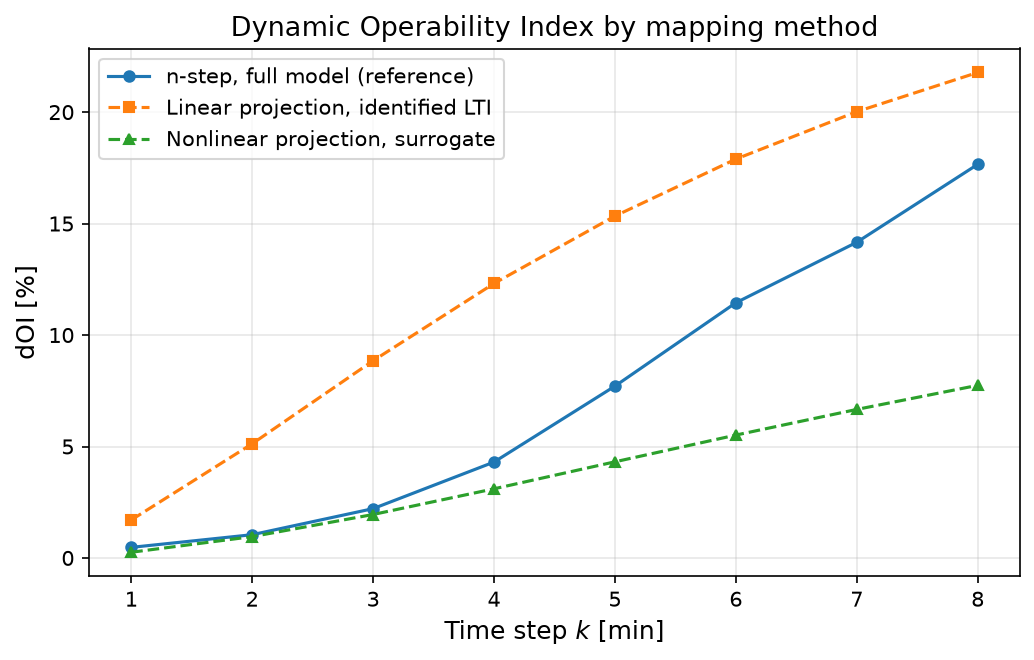

Computational cost: n-step 41 s, linear 0.4 s, nonlinear projection 0.5 s


In [9]:
# dOI of each method against the same DOS
fig, ax = plt.subplots(figsize=(7, 4.5))
steps = np.arange(1, k_max + 1)
for (name, res), mark in zip(comparison.items(), ['o-', 's--', '^--']):
    ax.plot(steps, res['dOI'], mark, label=name, markersize=5)
ax.set_xlabel('Time step $k$ [min]', fontsize=12)
ax.set_ylabel('dOI [%]', fontsize=12)
ax.set_title('Dynamic Operability Index by mapping method', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Computational cost: n-step {t_nstep:.0f} s, '
      f'linear {t_linear:.1f} s, nonlinear projection {t_nonlinear:.1f} s')

The overlay and the dOI curves show what each simplification costs:

- The **linear projection** is essentially free once the model is identified, but inherits the LTI fit's limits: it overestimates early operability (the first-order lags respond immediately, while the real reactor has a transport delay) and under-reaches the high-benzene corner where the gain nonlinearity matters.
- The **nonlinear projection** on the surrogate recovers the funnel's nonlinear gain directions at the same negligible cost, but its two-state dynamics give thinner transient slices and a conservative dOI.
- The **n-step method on the full model** is the reference: every state is propagated exactly, at two orders of magnitude more computation and with no state funnel.

The three are complementary: use the linear model for fast online funnels and recovery-horizon estimates, verify against the full-model n-step funnel offline, and bring in a nonlinear surrogate when the gain nonlinearity over the AIS is too strong for an LTI fit.

### Conclusions

**Key Results:**

- All three dynamic operability mapping methods were applied to the same DMA-MR problem; the projection methods required reduced models (an identified 4-state LTI and a 2-state nonlinear surrogate), since state-polytope propagation is intractable for the 160-state rigorous model.
- The full-model n-step funnel (reference) costs about $40$ s; both projection methods run in under a second after a one-time identification cost of about $20$ s.
- The linear method overestimates the dOI at early times and misses the nonlinear gain directions; the nonlinear surrogate captures the funnel shape better but is conservative in area; the differences are directly visible in the overlaid funnels.

**Workflow Summary:**

1. Map the reference funnel with ``dynamic_operability(..., method='nstep')`` on the rigorous model.
2. Identify an LTI model from step tests and map the funnel through the matrices interface (linear projection).
3. Fit a low-order nonlinear surrogate (steady-state gain map + identified dynamics) and map the funnel with ``method='projection'``.
4. Overlay the funnels with ``plot_funnel_comparison`` and compare the dOI of each method.